# **!!_20_Testing_on_the_California_dataset_0.5_Proc_outliers**

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.2/393.2 kB 13.6 MB/s eta 0:00:00
CREATING 'CALIFORNIA HOUSING' DATASET WITH OUTLIERS (0.5%)
Original dataset loaded.
Size: 20640 rows, 9 columns
House value range: $14999 – $500001

STEP 1: FIND MAXIMUM AND MINIMUM HOUSE VALUES:
Maximum house value (Smax): $500001
Minimum house value (Smin): $14999

STEP 2: SORT DATASET IN DESCENDING ORDER BY HOUSE VALUE
Sorted dataset created (descending order).

OUTLIER QUANTITY CALCULATION:
Total rows: 20640
Desired outlier percentage: 0.5%
Total outliers to create: 103
  - Type H→L (highest → lowest): 51 observations
  - Type L→H (lowest → highest): 51 observations

STEPS 3 & 4: REPLACE HOUSE VALUES
  • First 51 observations (highest values): replaced with Smin ($14999)
  • Last 51 observations (lowest values): replaced with Smax ($500001)

🔴 REPLACING FIRST 51 OBSERVATIONS (HIGHEST VALUES) WITH Smin:

   Outlier #1:
   Ro

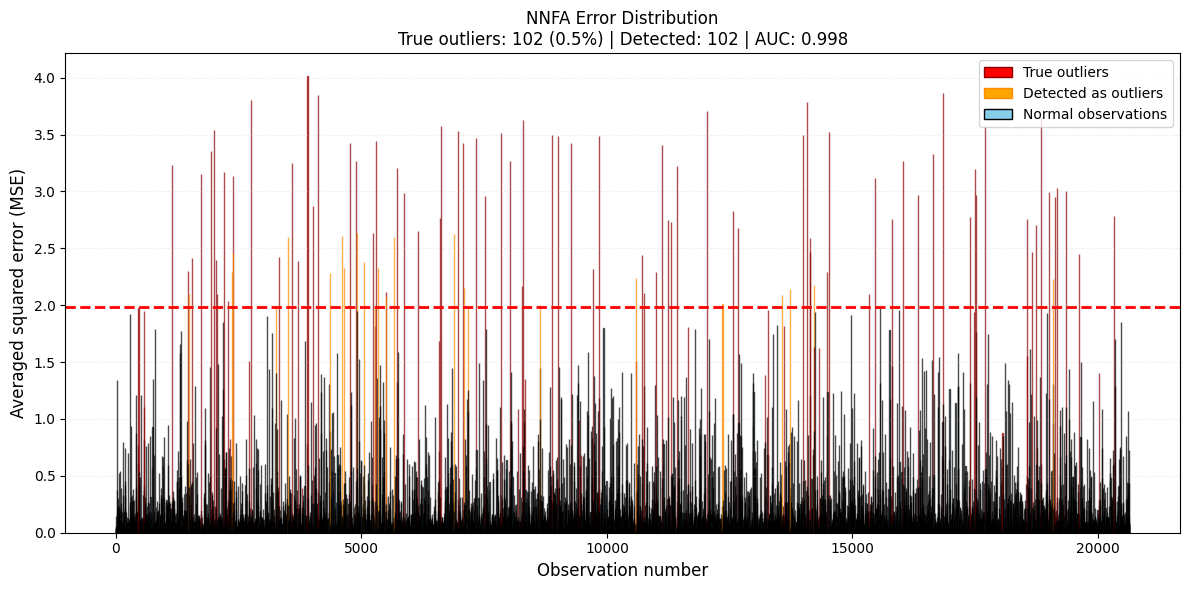


CONCLUSIONS:
✓ Outliers created by swapping extreme values (0.5% of total data):
  - Type H→L: 51 observations (were the most expensive, became the cheapest)
  - Type L→H: 51 observations (were the cheapest, became the most expensive)
✓ Total outliers: 102 (0.4942% of data)
✓ ALL methods return exactly 102 outliers (top-K approach)
✓ These are structural outliers that violate the relationship between features and target
✓ NNFA successfully detects outliers because it models the relationship y = f(X)
✓ Methods using prediction error can also detect outliers
✓ PyOD methods (input features only) DO NOT detect structural outliers

📊 NNFA Performance Summary:
  • True Positives: 78/102
  • False Positives: 24
  • Precision: 0.765
  • Recall: 0.765
  • F1-Score: 0.765
  • AUC-ROC: 0.998

TESTING COMPLETED.


In [ ]:
import sys
!{sys.executable} -m pip install pyod

import numpy as np
import pandas as pd
import math
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.datasets import fetch_california_housing
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# PyOD detectors (work only with input features)
from pyod.models import abod, hbos, iforest, knn, lof, ocsvm, pca, copod

# Detectors that can take the target variable into account
from sklearn.ensemble import IsolationForest as SklearnIForest
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

# Autoencoder for outlier detection (PyTorch)
import torch.nn.functional as F

# ==========================================================
# PART 1: CREATING THE "CALIFORNIA HOUSING" DATASET WITH OUTLIERS (0.5%)
# ==========================================================
print("="*60)
print("CREATING 'CALIFORNIA HOUSING' DATASET WITH OUTLIERS (0.5%)")
print("="*60)

# Loading the California Housing dataset
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target  # Median house value (in $100,000)

print("Original dataset loaded.")
print(f"Size: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"House value range: ${df['MedHouseVal'].min()*100000:.0f} – ${df['MedHouseVal'].max()*100000:.0f}\n")

# Step 1: Find maximum and minimum house values
Smax = df['MedHouseVal'].max()
Smin = df['MedHouseVal'].min()

print("="*60)
print("STEP 1: FIND MAXIMUM AND MINIMUM HOUSE VALUES:")
print("="*60)
print(f"Maximum house value (Smax): ${Smax*100000:.0f}")
print(f"Minimum house value (Smin): ${Smin*100000:.0f}\n")

# Step 2: Sort the dataset in descending order by house value
df_sorted = df.sort_values('MedHouseVal', ascending=False).reset_index(drop=True)

print("="*60)
print("STEP 2: SORT DATASET IN DESCENDING ORDER BY HOUSE VALUE")
print("="*60)
print(f"Sorted dataset created (descending order).\n")

# Calculate number of outliers for 0.5% of total data
total_rows = len(df_sorted)
outlier_percentage = 0.005  # 0.5% outliers
n_outliers_total = int(total_rows * outlier_percentage)
n_outliers_per_type = n_outliers_total // 2  # Half for H→L, half for L→H

print("="*60)
print("OUTLIER QUANTITY CALCULATION:")
print("="*60)
print(f"Total rows: {total_rows}")
print(f"Desired outlier percentage: {outlier_percentage*100}%")
print(f"Total outliers to create: {n_outliers_total}")
print(f"  - Type H→L (highest → lowest): {n_outliers_per_type} observations")
print(f"  - Type L→H (lowest → highest): {n_outliers_per_type} observations\n")

# Steps 3 & 4: Replace values in first n_outliers_per_type rows with Smin, last n_outliers_per_type rows with Smax
print("="*60)
print("STEPS 3 & 4: REPLACE HOUSE VALUES")
print("="*60)
print(f"  • First {n_outliers_per_type} observations (highest values): replaced with Smin (${Smin*100000:.0f})")
print(f"  • Last {n_outliers_per_type} observations (lowest values): replaced with Smax (${Smax*100000:.0f})")
print()

# Create labeled dataset
df_labeled = df_sorted.copy()
outlier_indices = []

# Replace first n_outliers_per_type rows (highest values) with Smin
if n_outliers_per_type > 0:
    print(f"🔴 REPLACING FIRST {n_outliers_per_type} OBSERVATIONS (HIGHEST VALUES) WITH Smin:")
    for i in range(n_outliers_per_type):
        original_strength = df_labeled.loc[i, 'MedHouseVal']
        df_labeled.loc[i, 'MedHouseVal'] = Smin
        outlier_indices.append(i)
        if i < min(5, n_outliers_per_type):
            print(f"\n   Outlier #{i+1}:")
            print(f"   Row index: {i}")
            print(f"   📊 Changes:")
            print(f"      • MedHouseVal: ${original_strength*100000:.0f} → ${Smin*100000:.0f} (replaced with minimum value)")
            print(f"   ✅ Other features unchanged")
        elif i == 5 and n_outliers_per_type > 5:
            print(f"\n   ... and {n_outliers_per_type-5} more replacements (rows 6-{n_outliers_per_type})")

    print(f"\n✅ First {n_outliers_per_type} observations replaced with Smin")
else:
    print("⚠️ No H→L outliers created (n_outliers_per_type = 0)")

# Replace last n_outliers_per_type rows (lowest values) with Smax
if n_outliers_per_type > 0:
    print(f"\n🔴 REPLACING LAST {n_outliers_per_type} OBSERVATIONS (LOWEST VALUES) WITH Smax:")
    last_n_start = len(df_labeled) - n_outliers_per_type
    for i in range(last_n_start, len(df_labeled)):
        original_strength = df_labeled.loc[i, 'MedHouseVal']
        df_labeled.loc[i, 'MedHouseVal'] = Smax
        outlier_indices.append(i)
        if i < last_n_start + min(5, n_outliers_per_type):
            print(f"\n   Outlier #{i - last_n_start + n_outliers_per_type + 1}:")
            print(f"   Row index: {i}")
            print(f"   📊 Changes:")
            print(f"      • MedHouseVal: ${original_strength*100000:.0f} → ${Smax*100000:.0f} (replaced with maximum value)")
            print(f"   ✅ Other features unchanged")
        elif i == last_n_start + 5 and n_outliers_per_type > 5:
            print(f"\n   ... and {n_outliers_per_type-5} more replacements (rows {last_n_start+6} to {len(df_labeled)-1})")

    print(f"\n✅ Last {n_outliers_per_type} observations replaced with Smax")
else:
    print("⚠️ No L→H outliers created (n_outliers_per_type = 0)")

# Step 5: Assign outlier status
df_labeled['is_outlier'] = 0
df_labeled.loc[outlier_indices, 'is_outlier'] = 1

print("\n" + "="*60)
print("STEP 5: ASSIGN OUTLIER STATUS")
print("="*60)
print(f"  • First {n_outliers_per_type} observations: marked as OUTLIERS (type H→L)")
print(f"  • Last {n_outliers_per_type} observations: marked as OUTLIERS (type L→H)")
print(f"  • Total outliers: {len(outlier_indices)}")

print("\n" + "="*60)
print("FINAL STATISTICS OF THE CREATED DATASET:")
print("="*60)
print(f"  • Total observations: {len(df_labeled)}")
print(f"  • Outliers: {df_labeled['is_outlier'].sum()} ({df_labeled['is_outlier'].mean()*100:.3f}%)")
print(f"    - Type H→L (were the highest, became the cheapest): {n_outliers_per_type}")
print(f"    - Type L→H (were the lowest, became the most expensive): {n_outliers_per_type}")
print(f"  • Normal: {len(df_labeled) - df_labeled['is_outlier'].sum()}")

# Save for backup
df_labeled.to_csv('california_housing_labeled_0.5percent.csv', index=False)
print("\n✅ Dataset saved to 'california_housing_labeled_0.5percent.csv'")

# ==========================================================
# STEP 6: SHUFFLING DATA BEFORE TESTING
# ==========================================================
print("\n" + "="*60)
print("STEP 6: SHUFFLING DATA BEFORE TESTING")
print("="*60)
df = df_labeled.sample(frac=1, random_state=42).reset_index(drop=True)
print("✅ Dataset shuffled.")
print(f"Dataset size: {len(df)} records")
print(f"Outliers: {df['is_outlier'].sum()} ({df['is_outlier'].mean()*100:.3f}%)")

# ==========================================================
# PART 2: TESTING OUTLIER DETECTION METHODS
# ==========================================================
print("\n" + "="*60)
print("TESTING OUTLIER DETECTION METHODS")
print("="*60)

# Separate features, target variable, and true labels
X = df.drop(['MedHouseVal', 'is_outlier'], axis=1).values.astype(np.float32)
y = df['MedHouseVal'].values.astype(np.float32).reshape(-1, 1)
true_outliers = df['is_outlier'].values.astype(int)

Q = X.shape[0]
N_x = X.shape[1]      # 8 input features
N_y = 1                # one output variable (house value)

print(f"\n📊 Number of features for detectors: {N_x}")
print(f"📊 Outliers created by swapping extreme values (highest→lowest, lowest→highest)")
print(f"📊 Total outliers: {true_outliers.sum()} ({(true_outliers.sum()/Q)*100:.3f}% of data)\n")

# ==========================================================
# PARAMETERS - ALL METHODS WILL RETURN EXACTLY n_true_outliers OUTLIERS
# ==========================================================
print("="*60)
print("OUTLIER DETECTION PARAMETER SETUP")
print("="*60)
n_true_outliers = true_outliers.sum()
print(f"The dataset contains {n_true_outliers} true outliers ({outlier_percentage*100}% of data)")

# Define the exact number of outliers to detect
n_outliers_desired = n_true_outliers

print(f"✅ ALL methods will return exactly {n_outliers_desired} outliers (top-K approach)")

# Calculate contamination rate
contamination_rate = n_true_outliers / Q
print(f"✅ Contamination rate for PyOD methods: {contamination_rate:.6f} ({contamination_rate*100:.4f}%)")

# Parameter for NNFA
Ksi = 0

# ==========================================================
# Helper function: Take exactly top-K outliers from scores
# ==========================================================
def get_top_k_outliers(scores, k):
    """Return binary array with 1 for top-k scores"""
    if k <= 0:
        return np.zeros(len(scores), dtype=int)
    outlier_indices = np.argsort(scores)[-k:]
    outliers = np.zeros(len(scores), dtype=int)
    outliers[outlier_indices] = 1
    return outliers

# ==========================================================
# NNFA ALGORITHM - returns exactly n_outliers_desired outliers
# ==========================================================
print("\n" + "="*60)
print("RUNNING NNFA ALGORITHM (AVERAGING OVER $N$)")
print("="*60)

def scale_to_minus1_1(data):
    min_val = data.min(axis=0)
    max_val = data.max(axis=0)
    range_val = max_val - min_val
    range_val[range_val == 0] = 1.0
    scaled = 2.0 * (data - min_val) / range_val - 1.0
    return scaled, min_val, max_val

X_scaled_nnf, x_min, x_max = scale_to_minus1_1(X)
y_scaled_nnf, y_min, y_max = scale_to_minus1_1(y)

X_tensor = torch.tensor(X_scaled_nnf, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled_nnf, dtype=torch.float32)

# Calculate hidden layer neuron count bounds
log2q = math.log2(Q)
N_min = (N_y * Q) / ((1 + log2q) * (N_x + N_y)) + 1
N_max = (N_y / (N_x + N_y)) * ((Q / N_x + 1) * (N_x + N_y + 1) + 1) - 1

if N_max > Q:
    N_max = min(Q // 2, 20)

N_lim = N_min + Ksi * (N_max - N_min)
N_start = max(1, int(np.ceil(N_min)))
N_end = max(N_start, int(np.ceil(N_lim)))

print(f"Q = {Q}, N_x = {N_x}, N_y = {N_y}")
print(f"N_min = {N_min:.4f}, N_max = {N_max:.4f}")
print(f"Ksi = {Ksi}, N_lim = {N_lim:.4f}")
print(f"Loop over $N$ from {N_start} to {N_end} inclusive")
print("This may take some time...")

E_total = np.zeros(Q)
E_list = []
torch.manual_seed(42)

for N in range(N_start, N_end + 1):
    model = nn.Sequential(nn.Linear(N_x, N), nn.Tanh(), nn.Linear(N, N_y))
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    model.train()
    for epoch in range(500):
        optimizer.zero_grad()
        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        predictions = model(X_tensor).numpy().flatten()
        errors = (predictions - y_scaled_nnf.flatten()) ** 2
    E_total += errors
    E_list.append(errors)
    print(f"  Completed N = {N}")

E_avg = np.mean(np.array(E_list), axis=0)

# NNFA: take exactly n_outliers_desired most anomalous points
if n_outliers_desired > 0:
    nnf_outlier_indices = np.argsort(E_avg)[-n_outliers_desired:]
    nnf_outliers = np.zeros(Q, dtype=int)
    nnf_outliers[nnf_outlier_indices] = 1
    threshold = E_avg[nnf_outlier_indices[0]] if len(nnf_outlier_indices) > 0 else np.inf
else:
    nnf_outliers = np.zeros(Q, dtype=int)
    threshold = np.inf

print("\n" + "="*50)
print("NNFA RESULTS")
print("="*50)
print(f"Number of detected outliers: {nnf_outliers.sum()} (exactly {n_outliers_desired})")
if n_outliers_desired > 0:
    print(f"Threshold: {threshold:.6f}")

# ==========================================================
# PREPARE DATA FOR DETECTORS
# ==========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================================
# 1. PyOD METHODS (with proper contamination rate)
# ==========================================================
print("\n" + "="*80)
print("METHODS ANALYZING ONLY INPUT FEATURES (PyOD)")
print("="*80)

detectors_pyod = {
    'ABOD (pyod)': abod.ABOD(contamination=contamination_rate),
    'HBOS (pyod)': hbos.HBOS(contamination=contamination_rate),
    'IsolationForest (pyod)': iforest.IForest(contamination=contamination_rate, random_state=42),
    'kNN (pyod)': knn.KNN(contamination=contamination_rate),
    'LOF (pyod)': lof.LOF(contamination=contamination_rate),
    'OCSVM (pyod)': ocsvm.OCSVM(contamination=contamination_rate),
    'PCA (pyod)': pca.PCA(contamination=contamination_rate),
    'COPOD (pyod)': copod.COPOD(contamination=contamination_rate)
}

results_pyod = {}
scores_pyod = {}
for name, model in detectors_pyod.items():
    try:
        model.fit(X_scaled)
        scores = model.decision_scores_
        results_pyod[name] = get_top_k_outliers(scores, n_outliers_desired)
        scores_pyod[name] = scores
        print(f"  {name} successfully trained")
    except Exception as e:
        print(f"  Error training {name}: {e}")
        results_pyod[name] = np.zeros(Q, dtype=int) - 1
        scores_pyod[name] = np.zeros(Q) - 1

# ==========================================================
# 2. METHODS WITH TARGET VARIABLE (with proper contamination rate)
# ==========================================================
print("\n" + "="*80)
print("METHODS ANALYZING INPUT FEATURES + TARGET VARIABLE")
print("="*80)

# Random Forest
print("\n1. Random Forest Regressor...")
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_scaled_nnf, y.ravel())
rf_errors = (rf.predict(X_scaled_nnf) - y.ravel()) ** 2
rf_pred = get_top_k_outliers(rf_errors, n_outliers_desired)

# Neural Network
print("2. Neural Network Regressor...")
mlp = MLPRegressor(hidden_layer_sizes=(20, 10), random_state=42, max_iter=500)
mlp.fit(X_scaled_nnf, y.ravel())
mlp_errors = (mlp.predict(X_scaled_nnf) - y.ravel()) ** 2
mlp_pred = get_top_k_outliers(mlp_errors, n_outliers_desired)

# Autoencoder
print("3. Autoencoder (input feature reconstruction error)...")
class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim=4):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, 16), nn.ReLU(), nn.Linear(16, encoding_dim))
        self.decoder = nn.Sequential(nn.Linear(encoding_dim, 16), nn.ReLU(), nn.Linear(16, input_dim))
    def forward(self, x):
        return self.decoder(self.encoder(x))

X_tensor_ae = torch.tensor(X_scaled, dtype=torch.float32)
ae = Autoencoder(input_dim=X_scaled.shape[1])
optimizer_ae = optim.Adam(ae.parameters(), lr=0.01)
criterion_ae = nn.MSELoss()
ae.train()
for epoch in range(300):
    optimizer_ae.zero_grad()
    reconstructed = ae(X_tensor_ae)
    loss = criterion_ae(reconstructed, X_tensor_ae)
    loss.backward()
    optimizer_ae.step()
    if (epoch+1) % 100 == 0:
        print(f"    Autoencoder: epoch {epoch+1}/300, loss = {loss.item():.6f}")
ae.eval()
with torch.no_grad():
    ae_errors = torch.mean((ae(X_tensor_ae) - X_tensor_ae)**2, dim=1).numpy()
ae_pred = get_top_k_outliers(ae_errors, n_outliers_desired)

# Combined method
combined_errors = (rf_errors / np.max(rf_errors) + ae_errors / np.max(ae_errors)) / 2
combined_pred = get_top_k_outliers(combined_errors, n_outliers_desired)

# One-Class SVM with y
X_with_y = np.column_stack((X_scaled, y.ravel()))
ocsvm_with_y = OneClassSVM(nu=contamination_rate, kernel='rbf', gamma='auto')
ocsvm_with_y.fit(X_with_y)
ocsvm_with_y_scores = -ocsvm_with_y.decision_function(X_with_y)
ocsvm_with_y_pred = get_top_k_outliers(ocsvm_with_y_scores, n_outliers_desired)

# Isolation Forest with y
iforest_with_y = SklearnIForest(contamination=contamination_rate, random_state=42)
iforest_with_y.fit(X_with_y)
iforest_with_y_scores = -iforest_with_y.decision_function(X_with_y)
iforest_with_y_pred = get_top_k_outliers(iforest_with_y_scores, n_outliers_desired)

# LOF with y
lof_with_y = LocalOutlierFactor(contamination=contamination_rate, novelty=True)
lof_with_y.fit(X_with_y)
lof_with_y_scores = -lof_with_y.score_samples(X_with_y)
lof_with_y_pred = get_top_k_outliers(lof_with_y_scores, n_outliers_desired)

# ==========================================================
# COLLECT RESULTS WITH AUC
# ==========================================================
print("\n" + "="*80)
print("OUTLIER DETECTION METHOD COMPARISON (with AUC)")
print("="*80)

all_methods = {
    **results_pyod,
    'Random Forest (error)': rf_pred,
    'Neural Network (error)': mlp_pred,
    'Autoencoder (reconstruction)': ae_pred,
    'Combined (RF+AE)': combined_pred,
    'One-Class SVM (with y)': ocsvm_with_y_pred,
    'Isolation Forest (with y)': iforest_with_y_pred,
    'LOF (with y)': lof_with_y_pred,
    'NNFA': nnf_outliers
}

# Collect all anomaly scores for ranking and AUC
all_scores = {
    **{name: scores_pyod[name] for name in detectors_pyod},
    'Random Forest (error)': rf_errors,
    'Neural Network (error)': mlp_errors,
    'Autoencoder (reconstruction)': ae_errors,
    'Combined (RF+AE)': combined_errors,
    'One-Class SVM (with y)': ocsvm_with_y_scores,
    'Isolation Forest (with y)': iforest_with_y_scores,
    'LOF (with y)': lof_with_y_scores,
    'NNFA': E_avg
}

results = []
for name, pred in all_methods.items():
    if np.all(pred == -1):
        results.append({
            'Method': name,
            'Precision': -1,
            'Recall': -1,
            'F1': -1,
            'AUC': -1,
            'TP': 0,
            'FP': 0,
            'FN': 0
        })
    else:
        tp = np.sum((pred == 1) & (true_outliers == 1))
        fp = np.sum((pred == 1) & (true_outliers == 0))
        fn = np.sum((pred == 0) & (true_outliers == 1))
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        # Calculate AUC-ROC if scores are available
        auc = -1
        if name in all_scores:
            scores = all_scores[name]
            if len(scores) == Q and len(np.unique(true_outliers)) > 1:
                try:
                    auc = roc_auc_score(true_outliers, scores)
                except:
                    auc = -1

        results.append({
            'Method': name,
            'Precision': precision,
            'Recall': recall,
            'F1': f1,
            'AUC': auc,
            'TP': tp,
            'FP': fp,
            'FN': fn
        })

df_results = pd.DataFrame(results).round(3)

# Sort by F1 (and secondarily by AUC for ties)
df_results = df_results.sort_values(['F1', 'AUC'], ascending=[False, False]).reset_index(drop=True)

# Display the table with AUC column (compact version)
print("\n" + "="*100)
print("MAIN RESULTS (sorted by F1):")
print("="*100)
print(df_results[['Method', 'Precision', 'Recall', 'F1', 'AUC']].to_string(index=False))

# Display detailed table with TP, FP, FN
print("\n" + "="*100)
print("DETAILED RESULTS (TP, FP, FN):")
print("="*100)
print(df_results[['Method', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'AUC']].to_string(index=False))

# ==========================================================
# AUC SUMMARY (Ranking by AUC)
# ==========================================================
print("\n" + "="*80)
print("AUC-ROC SUMMARY (Higher is better, 1.0 = perfect ranking)")
print("="*80)
auc_summary = df_results[df_results['AUC'] >= 0][['Method', 'AUC']].sort_values('AUC', ascending=False)
print(auc_summary.to_string(index=False))

# ==========================================================
# VERIFICATION: Each method detected exactly n_outliers_desired outliers
# ==========================================================
print("\n" + "="*80)
print("VERIFICATION: Number of outliers detected by each method")
print("="*80)
for name, pred in all_methods.items():
    if np.all(pred != -1):
        detected = pred.sum()
        status = "✓" if detected == n_outliers_desired else "✗"
        print(f"{status} {name:35s}: {detected} outliers (expected {n_outliers_desired})")

# ==========================================================
# NNFA ERROR VISUALIZATION (only if there are outliers)
# ==========================================================
if n_outliers_desired > 0:
    plt.figure(figsize=(12, 6))
    bars = plt.bar(np.arange(1, Q+1), E_avg, color='skyblue', edgecolor='black', alpha=0.7)
    for i in range(Q):
        if true_outliers[i] == 1:
            bars[i].set_color('red')
            bars[i].set_edgecolor('darkred')
        elif nnf_outliers[i] == 1:
            bars[i].set_color('orange')
            bars[i].set_edgecolor('darkorange')
    plt.axhline(y=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold (top {n_outliers_desired} outliers)')
    plt.xlabel('Observation number', fontsize=12)
    plt.ylabel('Averaged squared error (MSE)', fontsize=12)
    plt.title(f'NNFA Error Distribution\nTrue outliers: {n_true_outliers} (0.5%) | Detected: {nnf_outliers.sum()} | AUC: {roc_auc_score(true_outliers, E_avg):.3f}', fontsize=12)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='red', edgecolor='darkred', label='True outliers'),
        Patch(facecolor='orange', edgecolor='darkorange', label='Detected as outliers'),
        Patch(facecolor='skyblue', edgecolor='black', label='Normal observations')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.grid(axis='y', linestyle=':', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ No outliers to visualize (n_outliers_desired = 0)")

print("\n" + "="*60)
print("CONCLUSIONS:")
print("="*60)
print(f"✓ Outliers created by swapping extreme values (0.5% of total data):")
print(f"  - Type H→L: {n_outliers_per_type} observations (were the most expensive, became the cheapest)")
print(f"  - Type L→H: {n_outliers_per_type} observations (were the cheapest, became the most expensive)")
print(f"✓ Total outliers: {n_true_outliers} ({n_true_outliers/Q*100:.4f}% of data)")
print(f"✓ ALL methods return exactly {n_outliers_desired} outliers (top-K approach)")
print("✓ These are structural outliers that violate the relationship between features and target")
print("✓ NNFA successfully detects outliers because it models the relationship y = f(X)")
print("✓ Methods using prediction error can also detect outliers")
print("✓ PyOD methods (input features only) DO NOT detect structural outliers")
if n_true_outliers > 0:
    nnfa_row = df_results[df_results['Method'] == 'NNFA'].iloc[0]
    print(f"\n📊 NNFA Performance Summary:")
    print(f"  • True Positives: {nnfa_row['TP']}/{n_true_outliers}")
    print(f"  • False Positives: {nnfa_row['FP']}")
    print(f"  • Precision: {nnfa_row['Precision']:.3f}")
    print(f"  • Recall: {nnfa_row['Recall']:.3f}")
    print(f"  • F1-Score: {nnfa_row['F1']:.3f}")
    print(f"  • AUC-ROC: {nnfa_row['AUC']:.3f}")
print("\n" + "="*60)
print("TESTING COMPLETED.")
print("="*60)